In [18]:
import numpy as np
import torch
import math

from reader import *
from encoder import *

bunny_model = Reader.read_from_file('assets/bunny.obj')

baseline_encoder = BaselineEncoder()
baseline_compressed_model = baseline_encoder.encode(bunny_model)

import matplotlib.pyplot as plt


def print_statistics(compressed_model, name):
    print(f"{name} statistics:")
    print(f"- Bytes per triangle: {compressed_model.bits_per_triangle / 8:.2f}")
    print(f"- Bytes per vertex: {compressed_model.bits_per_vertex / 8:.2f}")
    print(f"- Compression rate: {baseline_compressed_model.bits_per_vertex / compressed_model.bits_per_vertex:.2f}")


print_statistics(baseline_compressed_model, "BaselineEncoder")

BaselineEncoder statistics:
- Bytes per triangle: 18.05
- Bytes per vertex: 35.82
- Compression rate: 1.00


In [19]:
import pyvista as pv
import numpy as np

mesh = pv.read('assets/bunny.obj')

plotter = pv.Plotter()

# Add initial mesh actor (with faces visible)
actor = plotter.add_mesh(
    mesh,
    opacity=1.0,
    show_edges=False,
    color="lightsteelblue",
)

# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    mesh.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)
plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:50169/index.html?ui=P_0x112fc919010_5&reconnect=auto" class="pyvis…

In [20]:
def compute_quantization_bits_for_residuals(
        original_points: np.ndarray,
        residuals: np.ndarray,
        epsilon: float = 0.01
) -> tuple[int, int, float, float]:
    """
    Given:
      - original_points: (N,3) array
      - residuals:        (N,3) array of residual vectors = (p_surf − p_c)
      - epsilon:          fraction of the original side length (e.g., 0.01 for 1%)

    Returns:
      - B: bits per coordinate needed to quantize residuals so that
           max quantization error ≤ epsilon * (original_bounding_side).
      - total_bits: 3 * B  (bits per residual‐vector)
      - side_orig:   original bounding cube side length
      - side_res:    residuals bounding cube side length

    Derivation:
      Let side_orig = max_range(original_points)  (i.e. side of AABB).
      We want quantization error ≤ ε * side_orig. For uniform quantization in each axis:
         step_res = side_res / (2^B)
         max_err_axis = step_res / 2
         we require:  step_res/2 ≤ ε * side_orig
                  ⇒ side_res / (2^B * 2) ≤ ε * side_orig
                  ⇒ 2^(B+1) ≥ side_res / (ε * side_orig)
                  ⇒ B ≥ log2( side_res/(ε*side_orig) ) − 1

      If side_res/(ε*side_orig) < 1, then log2(…) − 1 < 0 ⇒ B ≤ 0 ⇒ we clamp B to 0.
    """
    # 1) Compute original bounding cube side
    mins_orig = np.min(original_points, axis=0)  # (min_x, min_y, min_z)
    maxs_orig = np.max(original_points, axis=0)  # (max_x, max_y, max_z)
    ranges_orig = maxs_orig - mins_orig  # (range_x, range_y, range_z)
    side_orig = float(np.max(ranges_orig))

    # 2) Compute residual‐cloud bounding cube side
    mins_res = np.min(residuals, axis=0)
    maxs_res = np.max(residuals, axis=0)
    ranges_res = maxs_res - mins_res
    side_res = float(np.max(ranges_res))

    ratio = side_res / (epsilon * side_orig)
    # 3) Solve for B (bits per coordinate)
    #    2^(B+1) ≥ side_res/(ε * side_orig)
    #    B ≥ log2(side_res/(ε * side_orig)) − 1
    if side_res <= 0 or side_orig <= 0:
        # degenerate: if either side is zero, no bits are needed
        B = 0
    else:
        ratio = side_res / (epsilon * side_orig)
        # If ratio ≤ 1, then log2(ratio)−1 ≤ −1 => B ≤ 0 ⇒ clamp to 0
        if ratio <= 1.0:
            B = 0
        else:
            B = math.ceil(math.log2(ratio) - 1.0)

    total_bits = 3 * B
    return B, total_bits, side_orig, side_res

In [22]:
B, total_bits, side_orig, side_res = compute_quantization_bits_for_residuals(
    original_points=mesh.points,
    residuals=residuals,
    # epsilon=epsilon
)

print(f"Original bounding‐cube side (side_orig) = {side_orig:.6f}")
print(f"Residuals bounding‐cube side (side_res) = {side_res:.6e}")
print(f"Bits per coordinate needed (B) = {B}")
print(f"Total bits per residual‐vector = {total_bits}")

Original bounding‐cube side (side_orig) = 0.155159
Residuals bounding‐cube side (side_res) = 1.551592e-01
Bits per coordinate needed (B) = 6
Total bits per residual‐vector = 18


In [31]:
import numpy as np
from scipy.optimize import least_squares
from tqdm import tqdm, trange


def fit_axis_aligned_ellipsoid_nn(
        points: np.ndarray,
        num_iters: int = 1000,
        lr: float = 1e-2,
        device: str = "cpu"
) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit an axis‐aligned ellipsoid to `points` by treating (x0,y0,z0,a,b,c) as
    learnable parameters in PyTorch and minimizing ∑[( (x−x0)/a )^2 + ((y−y0)/b)^2 + ((z−z0)/c)^2 − 1 ]^2
    via gradient descent.

    Returns:
        center: np.ndarray of shape (3,)  -- learned [x0, y0, z0]
        axes:   np.ndarray of shape (3,)  -- learned [a, b, c] (all > 0)
    """
    # Convert points to torch tensor on the chosen device
    pts = torch.from_numpy(points.astype(np.float32)).to(device)  # (N,3)

    # Initialize parameters:
    # center (x0,y0,z0) = centroid of points
    centroid = points.mean(axis=0).astype(np.float32)
    # axes (a,b,c) = half‐ranges in x,y,z
    mins = points.min(axis=0).astype(np.float32)
    maxs = points.max(axis=0).astype(np.float32)
    half_extents = ((maxs - mins) / 2.0).astype(np.float32)
    # Prevent zero initial axes:
    a0, b0, c0 = np.maximum(half_extents, 1e-3)

    # Create torch parameters with requires_grad=True
    x0 = torch.tensor(centroid[0], requires_grad=True, dtype=torch.float32, device=device)
    y0 = torch.tensor(centroid[1], requires_grad=True, dtype=torch.float32, device=device)
    z0 = torch.tensor(centroid[2], requires_grad=True, dtype=torch.float32, device=device)
    # To enforce positivity of a,b,c, we parametrize them via softplus of unconstrained variables:
    sa = torch.tensor(np.log(np.exp(a0) - 1.0), requires_grad=True, dtype=torch.float32, device=device)
    sb = torch.tensor(np.log(np.exp(b0) - 1.0), requires_grad=True, dtype=torch.float32, device=device)
    sc = torch.tensor(np.log(np.exp(c0) - 1.0), requires_grad=True, dtype=torch.float32, device=device)

    # Build optimizer over all parameters
    optimizer = torch.optim.Adam([x0, y0, z0, sa, sb, sc], lr=lr)

    for it in range(num_iters):
        optimizer.zero_grad()

        # Recover actual a,b,c via softplus to keep them > 0
        a = torch.nn.functional.softplus(sa)
        b = torch.nn.functional.softplus(sb)
        c = torch.nn.functional.softplus(sc)

        # Center points
        xc = (pts[:, 0] - x0) / a
        yc = (pts[:, 1] - y0) / b
        zc = (pts[:, 2] - z0) / c

        # Ellipsoid residual: f_i = xc^2 + yc^2 + zc^2 - 1
        f = xc * xc + yc * yc + zc * zc - 1.0  # (N,)

        # Loss = mean squared residual
        loss = torch.mean(f * f)

        loss.backward()
        optimizer.step()

        # Optional: print every 200 iterations
        if (it + 1) % 200 == 0 or it == 0:
            with torch.no_grad():
                print(f"Iter {it + 1}/{num_iters}, Loss = {loss.item():.6e}, "
                      f"a={a.item():.4f}, b={b.item():.4f}, c={c.item():.4f}")

    # After optimization, extract final center and axes
    with torch.no_grad():
        center = torch.stack((x0, y0, z0)).cpu().numpy()
        a = torch.nn.functional.softplus(sa).cpu().numpy()
        b = torch.nn.functional.softplus(sb).cpu().numpy()
        c = torch.nn.functional.softplus(sc).cpu().numpy()
        axes = np.array([a, b, c], dtype=np.float32)

    return center, axes


def compute_ellipsoid_residuals(
        points: np.ndarray,
        center: np.ndarray,
        axes: np.ndarray
) -> np.ndarray:
    """
    For each point p, compute the vector residual to the fitted ellipsoid:
      1) p_c = p − center
      2) denom = sqrt((x_c/a)^2 + (y_c/b)^2 + (z_c/c)^2)
         if denom > ε: t = 1/denom else t = 1
      3) p_surf = t * p_c
      4) residual = p_surf − p_c
    Returns array of shape (N,3).
    """
    pts_c = points - center.reshape(1, 3)
    a, b, c = axes
    x_c = pts_c[:, 0]
    y_c = pts_c[:, 1]
    z_c = pts_c[:, 2]

    denom = np.sqrt((x_c / a) ** 2 + (y_c / b) ** 2 + (z_c / c) ** 2).reshape(-1, 1)
    eps = 1e-12
    t = np.zeros_like(denom)
    nonzero = (denom.reshape(-1) > eps)
    t[nonzero] = 1.0 / denom[nonzero]
    t[~nonzero] = 1.0

    p_surf = pts_c * t
    residuals = p_surf - pts_c
    return residuals


def split_points_along_longest_axis(
        points: np.ndarray,
        center: np.ndarray,
        axes: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Split `points` into two subsets along the ellipsoid’s longest axis:
      1) idx = argmax(axes)
      2) split_val = center[idx]
      3) pts0: points[:,idx] < split_val; pts1: points[:,idx] >= split_val
    """
    idx = np.argmax(axes)
    # split_val = center[idx]
    # split_val = center[idx]
    coord = points[:, idx]
    split_val = (coord.max() + coord.min()) / 2.0
    mask0 = coord < split_val
    return points[mask0], points[~mask0]


class EllipsoidNode:
    """
    Node for hierarchical ellipsoid fit.
    Attributes:
      center:   (3,) fitted center
      axes:     (3,) fitted semi‐axes
      residuals:(N_subset, 3) residual vectors
      points:   (N_subset, 3) original subset
      children: [] or [child0, child1]
    """

    def __init__(self, center, axes, residuals, points):
        self.center = center
        self.axes = axes
        self.residuals = residuals
        self.points = points
        self.children = []


def fit_ellipsoids_hierarchical_nonlinear(
        points: np.ndarray,
        max_depth: int = 3
) -> EllipsoidNode:
    """
    Hierarchically fit ellipsoids to `points` up to `max_depth` levels,
    using nonlinear least‐squares at each node.

    Returns the root EllipsoidNode.
    """

    def recurse(sub_pts: np.ndarray, depth: int) -> EllipsoidNode:
        # 1) Nonlinear ellipsoid fit
        center, axes = fit_axis_aligned_ellipsoid_nn(sub_pts, num_iters=2000)
        # 2) Compute residuals
        residuals = compute_ellipsoid_residuals(sub_pts, center, axes)
        node = EllipsoidNode(center, axes, residuals, sub_pts)

        # 3) Split if not at max depth
        if depth < max_depth and sub_pts.shape[0] > 10:
            pts0, pts1 = split_points_along_longest_axis(residuals, center, axes)
            if pts0.shape[0] > 0 and pts1.shape[0] > 0:
                child0 = recurse(pts0, depth + 1)
                child1 = recurse(pts1, depth + 1)
                node.children = [child0, child1]
        return node

    return recurse(points, depth=1)


# Generate a noisy half‐sphere point cloud (arbitrary data)
def generate_noisy_half_sphere(
        radius: float = 1.0,
        num_theta: int = 60,
        num_phi: int = 120,
        noise_sigma: float = 0.02
) -> np.ndarray:
    """
    Sample a hemisphere plus Gaussian noise to simulate arbitrary shape data.
    """
    thetas = np.linspace(0, np.pi / 2, num_theta)
    phis = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)
    theta_grid, phi_grid = np.meshgrid(thetas, phis, indexing="ij")
    x = radius * np.sin(theta_grid) * np.cos(phi_grid)
    y = radius * np.sin(theta_grid) * np.sin(phi_grid)
    z = radius * np.cos(theta_grid)
    pts = np.vstack((x.flatten(), y.flatten(), z.flatten())).T
    pts += np.random.normal(scale=noise_sigma, size=pts.shape)
    return pts


pts = generate_noisy_half_sphere(radius=1.0, num_theta=60, num_phi=120, noise_sigma=0.2)

# Fit hierarchical ellipsoids nonlinearly to depth=3
root = fit_ellipsoids_hierarchical_nonlinear(mesh.points, max_depth=3)


# Traverse and print the hierarchy
def print_tree(node: EllipsoidNode, indent: int = 0):
    prefix = "  " * indent
    N = node.points.shape[0]
    print(f"{prefix}Depth {indent + 1}: {N} points")
    print(f"{prefix}  Center: {node.center}")
    print(f"{prefix}  Axes:   {node.axes}")
    if node.children:
        for child in node.children:
            print_tree(child, indent + 1)


print_tree(root)

Iter 1/2000, Loss = 1.991733e-01, a=0.0776, b=0.0768, c=0.0602
Iter 200/2000, Loss = 1.648100e-01, a=0.0748, b=0.0900, c=0.0579
Iter 400/2000, Loss = 1.648101e-01, a=0.0748, b=0.0900, c=0.0579
Iter 600/2000, Loss = 1.648779e-01, a=0.0749, b=0.0900, c=0.0579
Iter 800/2000, Loss = 1.648100e-01, a=0.0748, b=0.0900, c=0.0579
Iter 1000/2000, Loss = 1.648100e-01, a=0.0748, b=0.0900, c=0.0579
Iter 1200/2000, Loss = 1.648100e-01, a=0.0748, b=0.0900, c=0.0579
Iter 1400/2000, Loss = 1.648101e-01, a=0.0748, b=0.0900, c=0.0579
Iter 1600/2000, Loss = 1.648101e-01, a=0.0748, b=0.0900, c=0.0579
Iter 1800/2000, Loss = 1.648100e-01, a=0.0748, b=0.0900, c=0.0579
Iter 2000/2000, Loss = 1.648100e-01, a=0.0748, b=0.0900, c=0.0579
Iter 1/2000, Loss = 6.902985e-01, a=0.0373, b=0.0234, c=0.0353
Iter 200/2000, Loss = 6.058160e-02, a=0.0805, b=0.0369, c=0.0708
Iter 400/2000, Loss = 2.146450e-02, a=0.1474, b=0.0464, c=0.0938
Iter 600/2000, Loss = 1.066123e-02, a=0.2082, b=0.0537, c=0.1002
Iter 800/2000, Loss = 7

In [8]:
def generate_ellipsoid_point_cloud(
        center: np.ndarray,
        axes: np.ndarray,
        num_u: int = 50,
        num_v: int = 100
) -> np.ndarray:
    """
    Generate a point cloud sampling the surface of an axis-aligned ellipsoid.

    Parameters:
        center (np.ndarray of shape (3,)): [x0, y0, z0] = ellipsoid center.
        axes   (np.ndarray of shape (3,)): [a, b, c] = semi-axes lengths along x, y, z.
        num_u  (int): Number of latitude divisions (from 0 to π). Default = 50.
        num_v  (int): Number of longitude divisions (from 0 to 2π). Default = 100.

    Returns:
        pts (np.ndarray of shape (num_u * num_v, 3)):
            A list of [x, y, z] points on the ellipsoid surface.
    """
    x0, y0, z0 = center
    a, b, c = axes

    # Parameter ranges:
    #   u ∈ [0, π] (latitude)
    #   v ∈ [0, 2π) (longitude)
    us = np.linspace(0.0, np.pi, num_u)
    vs = np.linspace(0.0, 2.0 * np.pi, num_v, endpoint=False)

    # Construct a meshgrid of shape (num_u, num_v)
    u_grid, v_grid = np.meshgrid(us, vs, indexing="ij")

    # Parametric equations for an axis-aligned ellipsoid:
    #   x = x0 + a * sin(u) * cos(v)
    #   y = y0 + b * sin(u) * sin(v)
    #   z = z0 + c * cos(u)
    x_vals = x0 + a * np.sin(u_grid) * np.cos(v_grid)
    y_vals = y0 + b * np.sin(u_grid) * np.sin(v_grid)
    z_vals = z0 + c * np.cos(u_grid)

    # Flatten to a (N,3) array
    pts = np.vstack((x_vals.flatten(),
                     y_vals.flatten(),
                     z_vals.flatten())).T  # shape = (num_u*num_v, 3)

    return pts

In [9]:
plotter = pv.Plotter()

# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    mesh.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.add_points(
    generate_ellipsoid_point_cloud(root.center, root.axes),
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)
points_actor = plotter.add_points(
    root.residuals,
    color="blue",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:50169/index.html?ui=P_0x112fc930250_3&reconnect=auto" class="pyvis…

In [10]:
len(root.children[1].points)

115

In [11]:
plotter = pv.Plotter()

# points_actor = plotter.add_points(
#     root.points,
#     color="blue",
#     point_size=5,
#     render_points_as_spheres=True,
#     opacity=1.0,
# )
node = root.children[0]
# Also add a "point cloud" actor for the same vertices—but hide it by default.
points_actor = plotter.add_points(
    node.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.add_points(
    generate_ellipsoid_point_cloud(node.center, node.axes),
    color="green",
    point_size=5,
    render_points_as_spheres=True,
    opacity=1.0,
)

plotter.show(title="Interactive 3D Mesh Viewer", window_size=[800, 600])


Widget(value='<iframe src="http://localhost:50169/index.html?ui=P_0x112fc891410_4&reconnect=auto" class="pyvis…

In [24]:
parts = [root.children[0].children[0], root.children[0].children[1], root.children[1].children[0],
         root.children[1].children[1]]

for part in parts:
    residuals = part.residuals
    mins_res = np.min(residuals, axis=0)
    maxs_res = np.max(residuals, axis=0)
    ranges_res = maxs_res - mins_res
    print(ranges_res)
    side_res = float(np.max(ranges_res))


    residual_model_bits_needed = math.ceil(math.log2(side_res / (side_orig * 0.0005)))
    # residual_model_bits_needed
    print("residual_model_bits_needed: ", residual_model_bits_needed)
    total_bits_for_vertices_for_residual = residual_model_bits_needed * mesh.points.size
    # total_bits_for_vertices_for_residual
    # total_bits_for_vertices_for_original / total_bits_for_vertices_for_residual

[0.00964958 0.00061512 0.00052767]
residual_model_bits_needed:  7
[0.0179743  0.00149906 0.00344748]
residual_model_bits_needed:  8
[0.00029657 0.00072742 0.00016645]
residual_model_bits_needed:  4
[0.00102778 0.01119655 0.00153197]
residual_model_bits_needed:  8


# =============================================================================
# NEW APPROACH: Spherical Coordinates + Group-based Ellipsoid Fitting
# =============================================================================

In [70]:
# Task 1: Spherical Coordinate Transformation
# Convert Cartesian (x, y, z) to Spherical (r, θ, φ) relative to ellipsoid center

def cartesian_to_spherical(points: np.ndarray, center: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert Cartesian coordinates to spherical coordinates relative to a center point.
    
    Args:
        points: (N, 3) array of Cartesian coordinates
        center: (3,) array - the origin for spherical coordinates (ellipsoid center)
    
    Returns:
        r: (N,) radial distance from center
        theta: (N,) polar angle from z-axis, range [0, π]
        phi: (N,) azimuthal angle in xy-plane, range [0, 2π)
    """
    # Translate points to center
    pts_centered = points - center.reshape(1, 3)
    
    x = pts_centered[:, 0]
    y = pts_centered[:, 1]
    z = pts_centered[:, 2]
    
    # Radial distance
    r = np.sqrt(x**2 + y**2 + z**2)
    
    # Polar angle θ (from z-axis) - range [0, π]
    # θ = arccos(z / r), handle r=0 case
    theta = np.zeros_like(r)
    nonzero = r > 1e-12
    theta[nonzero] = np.arccos(np.clip(z[nonzero] / r[nonzero], -1.0, 1.0))
    
    # Azimuthal angle φ (in xy-plane) - range [0, 2π)
    phi = np.arctan2(y, x)
    phi = np.mod(phi, 2 * np.pi)  # Ensure [0, 2π)
    
    return r, theta, phi


def spherical_to_cartesian(r: np.ndarray, theta: np.ndarray, phi: np.ndarray, center: np.ndarray) -> np.ndarray:
    """
    Convert spherical coordinates back to Cartesian coordinates.
    
    Args:
        r: (N,) radial distances
        theta: (N,) polar angles [0, π]
        phi: (N,) azimuthal angles [0, 2π)
        center: (3,) the origin used for spherical coordinates
    
    Returns:
        points: (N, 3) Cartesian coordinates
    """
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    
    points = np.stack([x, y, z], axis=1) + center.reshape(1, 3)
    return points


# Test the transformation roundtrip
points_test = mesh.points
center_test = points_test.mean(axis=0)

r, theta, phi = cartesian_to_spherical(points_test, center_test)
points_reconstructed = spherical_to_cartesian(r, theta, phi, center_test)

max_error = np.max(np.abs(points_test - points_reconstructed))
print(f"Spherical transform roundtrip max error: {max_error:.2e}")
print(f"r range: [{r.min():.6f}, {r.max():.6f}]")
print(f"theta range: [{theta.min():.6f}, {theta.max():.6f}] (should be [0, π])")
print(f"phi range: [{phi.min():.6f}, {phi.max():.6f}] (should be [0, 2π))")

Spherical transform roundtrip max error: 1.73e-16
r range: [0.031391, 0.116678]
theta range: [0.033765, 3.090332] (should be [0, π])
phi range: [0.008070, 6.279098] (should be [0, 2π))


In [76]:
# Task 2: Group-based Ellipsoid Fitting
# Split vertices into groups of n, fit ellipsoid to each group

def split_into_groups(points: np.ndarray, group_size: int) -> list[np.ndarray]:
    """
    Split points into groups of approximately group_size points each.
    
    Args:
        points: (N, 3) array
        group_size: target size for each group
    
    Returns:
        List of (group_size, 3) arrays (last group may be smaller)
    """
    n_points = len(points)
    groups = []
    for i in range(0, n_points, group_size):
        groups.append(points[i:i + group_size])
    return groups


def fit_ellipsoid_to_group(points: np.ndarray, num_iters: int = 500) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit axis-aligned ellipsoid to a group of points using gradient descent.
    Reuses the existing fit_axis_aligned_ellipsoid_nn but with fewer iterations for speed.
    """
    return fit_axis_aligned_ellipsoid_nn(points, num_iters=num_iters, lr=1e-2)


@dataclass
class EllipsoidGroup:
    """Stores ellipsoid fit and spherical coordinates for a group of vertices."""
    center: np.ndarray      # (3,) ellipsoid center
    axes: np.ndarray        # (3,) ellipsoid semi-axes (a, b, c)
    theta: np.ndarray       # (n,) polar angles
    phi: np.ndarray         # (n,) azimuthal angles  
    r_actual: np.ndarray    # (n,) actual radial distances
    r_ellipsoid: np.ndarray # (n,) radial distances to ellipsoid surface
    residuals: np.ndarray   # (n,) radial residuals = r_actual - r_ellipsoid
    indices: np.ndarray     # (n,) original vertex indices


def ellipsoid_radius_at_direction(axes: np.ndarray, theta: np.ndarray, phi: np.ndarray) -> np.ndarray:
    """
    Compute the radial distance from ellipsoid center to surface in direction (θ, φ).
    
    For an axis-aligned ellipsoid with semi-axes (a, b, c):
    The point on ellipsoid in direction (θ, φ) is:
        x = a * sin(θ) * cos(φ)
        y = b * sin(θ) * sin(φ)
        z = c * cos(θ)
    
    The radial distance is sqrt(x² + y² + z²).
    """
    a, b, c = axes
    
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    sin_phi = np.sin(phi)
    cos_phi = np.cos(phi)
    
    x = a * sin_theta * cos_phi
    y = b * sin_theta * sin_phi
    z = c * cos_theta
    
    r_ellipsoid = np.sqrt(x**2 + y**2 + z**2)
    return r_ellipsoid


def fit_groups_with_ellipsoids(points: np.ndarray, group_size: int = 128, num_iters: int = 500) -> list[EllipsoidGroup]:
    """
    Main function: split points into groups, fit ellipsoid to each, compute spherical coords and residuals.
    """
    from dataclasses import dataclass
    
    n_points = len(points)
    groups = []
    
    for start_idx in tqdm(range(0, n_points, group_size), desc="Fitting ellipsoids"):
        end_idx = min(start_idx + group_size, n_points)
        group_points = points[start_idx:end_idx]
        group_indices = np.arange(start_idx, end_idx)
        
        # Fit ellipsoid to group
        center, axes = fit_ellipsoid_to_group(group_points, num_iters=num_iters)
        
        # Convert to spherical coordinates relative to ellipsoid center
        r_actual, theta, phi = cartesian_to_spherical(group_points, center)
        
        # Compute ellipsoid radius at each direction
        r_ellipsoid = ellipsoid_radius_at_direction(axes, theta, phi)
        
        # Radial residuals
        residuals = r_actual - r_ellipsoid
        
        groups.append(EllipsoidGroup(
            center=center,
            axes=axes,
            theta=theta,
            phi=phi,
            r_actual=r_actual,
            r_ellipsoid=r_ellipsoid,
            residuals=residuals,
            indices=group_indices
        ))
    
    return groups


# Test with group_size = 128
from dataclasses import dataclass

GROUP_SIZE = 128
ellipsoid_groups = fit_groups_with_ellipsoids(mesh.points, group_size=GROUP_SIZE, num_iters=500)

print(f"\nNumber of groups: {len(ellipsoid_groups)}")
print(f"Points per group: {GROUP_SIZE} (last group: {len(ellipsoid_groups[-1].indices)})")

Fitting ellipsoids:   0%|          | 0/20 [00:00<?, ?it/s]

Iter 1/500, Loss = 4.455358e-01, a=0.0704, b=0.0723, c=0.0483
Iter 200/500, Loss = 3.290788e-02, a=0.1157, b=0.1031, c=0.1024


Fitting ellipsoids:   5%|▌         | 1/20 [00:00<00:05,  3.50it/s]

Iter 400/500, Loss = 1.624650e-02, a=0.1408, b=0.1214, c=0.1648
Iter 1/500, Loss = 5.316385e-01, a=0.0744, b=0.0584, c=0.0436
Iter 200/500, Loss = 7.279673e-02, a=0.1024, b=0.1154, c=0.0897


Fitting ellipsoids:  10%|█         | 2/20 [00:00<00:05,  3.48it/s]

...

Iter 400/500, Loss = 1.220124e-02, a=0.1463, b=0.0499, c=0.0654
Iter 1/500, Loss = 5.633078e-01, a=0.0701, b=0.0577, c=0.0427
Iter 200/500, Loss = 1.954464e-02, a=0.0886, b=0.1078, c=0.0672


Fitting ellipsoids:  95%|█████████▌| 19/20 [00:05<00:00,  3.50it/s]

Iter 400/500, Loss = 1.317708e-02, a=0.0947, b=0.1498, c=0.0671
Iter 1/500, Loss = 7.471325e-01, a=0.0378, b=0.0710, c=0.0557
Iter 200/500, Loss = 2.712933e-02, a=0.0674, b=0.1043, c=0.1034


Fitting ellipsoids: 100%|██████████| 20/20 [00:05<00:00,  3.47it/s]

Iter 400/500, Loss = 1.644795e-02, a=0.0839, b=0.1077, c=0.1308

Number of groups: 20
Points per group: 128 (last group: 71)


=== Radial Residuals Analysis ===
Total vertices: 2503
Residual range: [-0.124031, 0.053369]
Residual std: 0.021392
Residual abs max: 0.124031

Original model max dimension: 0.155159
Residual range / original size: 1.1433


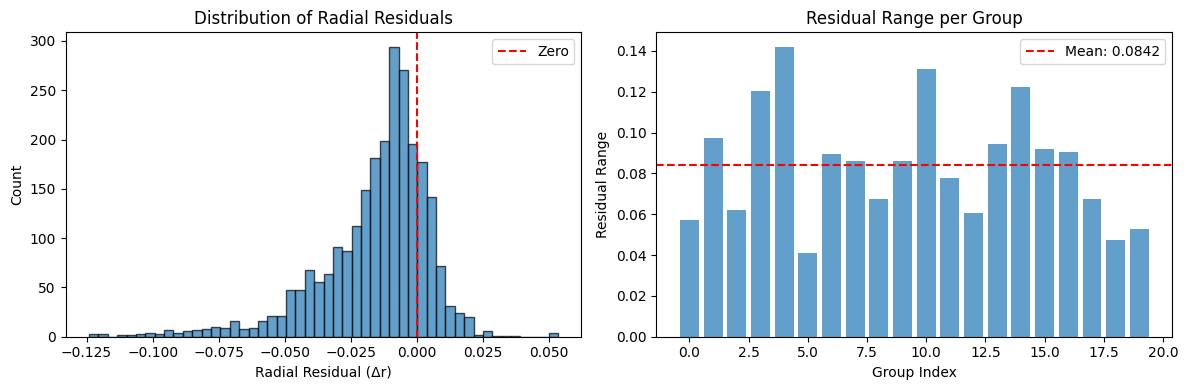


=== Bits needed per group (ε=0.0005) ===
Bits range: [10, 11]
Average bits for residual: 10.55


In [77]:
# Task 3 & 5: Analyze radial residuals

# Collect all residuals
all_residuals = np.concatenate([g.residuals for g in ellipsoid_groups])

print("=== Radial Residuals Analysis ===")
print(f"Total vertices: {len(all_residuals)}")
print(f"Residual range: [{all_residuals.min():.6f}, {all_residuals.max():.6f}]")
print(f"Residual std: {all_residuals.std():.6f}")
print(f"Residual abs max: {np.abs(all_residuals).max():.6f}")

# Compare to original model size
original_size = mesh.points.max(axis=0) - mesh.points.min(axis=0)
original_max_size = original_size.max()
print(f"\nOriginal model max dimension: {original_max_size:.6f}")
print(f"Residual range / original size: {(all_residuals.max() - all_residuals.min()) / original_max_size:.4f}")

# Plot histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Radial Residual (Δr)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Radial Residuals')
axes[0].axvline(x=0, color='r', linestyle='--', label='Zero')
axes[0].legend()

# Per-group residual ranges
group_ranges = [(g.residuals.max() - g.residuals.min()) for g in ellipsoid_groups]
axes[1].bar(range(len(group_ranges)), group_ranges, alpha=0.7)
axes[1].set_xlabel('Group Index')
axes[1].set_ylabel('Residual Range')
axes[1].set_title('Residual Range per Group')
axes[1].axhline(y=np.mean(group_ranges), color='r', linestyle='--', label=f'Mean: {np.mean(group_ranges):.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Calculate bits needed for residuals
epsilon = 0.0005  # target precision
bits_per_group = []
for g in ellipsoid_groups:
    res_range = g.residuals.max() - g.residuals.min()
    if res_range > 0:
        bits = max(1, math.ceil(math.log2(res_range / (original_max_size * epsilon))))
    else:
        bits = 1
    bits_per_group.append(bits)

print(f"\n=== Bits needed per group (ε={epsilon}) ===")
print(f"Bits range: [{min(bits_per_group)}, {max(bits_per_group)}]")
print(f"Average bits for residual: {np.mean(bits_per_group):.2f}")

In [78]:
# Derive required bits for angles and residuals from target max deviation
# 
# The reconstruction error comes from:
# 1. Angle quantization (θ, φ) → positional error ≈ r * Δangle
# 2. Residual quantization → positional error = Δr
#
# We split the error budget between these sources.

def calculate_required_bits(
    groups: list[EllipsoidGroup],
    max_deviation: float,
    error_split: tuple[float, float, float] = (1/3, 1/3, 1/3)
) -> tuple[int, int, list[int]]:
    """
    Calculate required bits for θ, φ, and residuals to achieve target max deviation.
    
    Args:
        groups: List of EllipsoidGroup with fitted ellipsoids
        max_deviation: Maximum allowed deviation in world units (e.g., ε * model_size)
        error_split: How to split error budget between (θ, φ, residual)
    
    Returns:
        theta_bits, phi_bits, residual_bits_per_group
    
    Derivation:
        Position = r * (sin(θ)cos(φ), sin(θ)sin(φ), cos(θ)) + center
        
        For angle θ with quantization step Δθ = π / 2^B_θ:
            Max error from θ ≈ r_max * (Δθ/2) = r_max * π / 2^(B_θ+1)
            
        For angle φ with quantization step Δφ = 2π / 2^B_φ:
            Max error from φ ≈ r_max * (Δφ/2) = r_max * π / 2^B_φ
            
        For residual with range R and B_r bits:
            Max error = R / 2^(B_r+1)
    """
    theta_budget, phi_budget, residual_budget = error_split
    
    # Find max radial distance across all groups (conservative estimate)
    r_max = max(g.r_actual.max() for g in groups)
    
    # θ bits: r_max * π / 2^(B+1) ≤ theta_budget * max_deviation
    # 2^(B+1) ≥ r_max * π / (theta_budget * max_deviation)
    # B ≥ log2(r_max * π / (theta_budget * max_deviation)) - 1
    theta_error_budget = theta_budget * max_deviation
    if theta_error_budget > 0:
        theta_bits = max(1, math.ceil(math.log2(r_max * np.pi / theta_error_budget) - 1))
    else:
        theta_bits = 16  # fallback
    
    # φ bits: r_max * π / 2^B ≤ phi_budget * max_deviation (note: 2π range, so step is 2π/2^B, error is π/2^B)
    # 2^B ≥ r_max * π / (phi_budget * max_deviation)
    phi_error_budget = phi_budget * max_deviation
    if phi_error_budget > 0:
        phi_bits = max(1, math.ceil(math.log2(r_max * np.pi / phi_error_budget)))
    else:
        phi_bits = 16  # fallback
    
    # Residual bits per group: range / 2^(B+1) ≤ residual_budget * max_deviation
    # 2^(B+1) ≥ range / (residual_budget * max_deviation)
    # B ≥ log2(range / (residual_budget * max_deviation)) - 1
    residual_error_budget = residual_budget * max_deviation
    residual_bits_per_group = []
    for g in groups:
        res_range = g.residuals.max() - g.residuals.min()
        if res_range > 0 and residual_error_budget > 0:
            bits = max(1, math.ceil(math.log2(res_range / residual_error_budget) - 1))
        else:
            bits = 1
        residual_bits_per_group.append(bits)
    
    return theta_bits, phi_bits, residual_bits_per_group


def quantize_value(value: float, min_val: float, max_val: float, bits: int) -> int:
    """Quantize a float value to an integer with given bit precision."""
    if max_val == min_val:
        return 0
    normalized = (value - min_val) / (max_val - min_val)
    max_int = (1 << bits) - 1
    return int(np.clip(np.round(normalized * max_int), 0, max_int))


def dequantize_value(quantized: int, min_val: float, max_val: float, bits: int) -> float:
    """Dequantize an integer back to float."""
    if bits == 0:
        return min_val
    max_int = (1 << bits) - 1
    if max_int == 0:
        return min_val
    normalized = quantized / max_int
    return min_val + normalized * (max_val - min_val)


def quantize_angles(theta: np.ndarray, phi: np.ndarray, theta_bits: int, phi_bits: int) -> tuple[np.ndarray, np.ndarray]:
    """Quantize angles to specified bit precision."""
    theta_q = np.array([quantize_value(t, 0, np.pi, theta_bits) for t in theta], dtype=np.uint32)
    phi_q = np.array([quantize_value(p, 0, 2*np.pi, phi_bits) for p in phi], dtype=np.uint32)
    return theta_q, phi_q


def dequantize_angles(theta_q: np.ndarray, phi_q: np.ndarray, theta_bits: int, phi_bits: int) -> tuple[np.ndarray, np.ndarray]:
    """Dequantize angles back to floats."""
    theta = np.array([dequantize_value(t, 0, np.pi, theta_bits) for t in theta_q])
    phi = np.array([dequantize_value(p, 0, 2*np.pi, phi_bits) for p in phi_q])
    return theta, phi


def decompress_full(groups: list[EllipsoidGroup], theta_bits: int, phi_bits: int, residual_bits_per_group: list[int]) -> np.ndarray:
    """
    Full decompression pipeline:
    1. Dequantize angles (θ, φ)
    2. Compute ellipsoid radius at dequantized direction
    3. Add dequantized residual
    4. Convert to Cartesian
    """
    all_points = []

    for g, res_bits in zip(groups, residual_bits_per_group):
        # Quantize and dequantize angles (simulates storage)
        theta_q, phi_q = quantize_angles(g.theta, g.phi, theta_bits, phi_bits)
        theta_deq, phi_deq = dequantize_angles(theta_q, phi_q, theta_bits, phi_bits)

        # Quantize and dequantize residuals
        res_min, res_max = g.residuals.min(), g.residuals.max()
        residuals_q = np.array([quantize_value(r, res_min, res_max, res_bits) for r in g.residuals], dtype=np.uint32)
        residuals_deq = np.array([dequantize_value(r, res_min, res_max, res_bits) for r in residuals_q])

        # Reconstruct: r = r_ellipsoid(θ', φ') + residual'
        r_ellipsoid = ellipsoid_radius_at_direction(g.axes, theta_deq, phi_deq)
        r_reconstructed = r_ellipsoid + residuals_deq

        # Convert to Cartesian
        points = spherical_to_cartesian(r_reconstructed, theta_deq, phi_deq, g.center)
        all_points.append(points)

    return np.vstack(all_points)


# Calculate required bits for target precision
EPSILON = 0.0005  # relative precision
MAX_DEVIATION = EPSILON * original_max_size  # absolute max deviation in world units

print(f"Target precision (ε): {EPSILON}")
print(f"Model max dimension: {original_max_size:.6f}")
print(f"Max allowed deviation: {MAX_DEVIATION:.6f}")

theta_bits_calc, phi_bits_calc, residual_bits_calc = calculate_required_bits(
    ellipsoid_groups, 
    MAX_DEVIATION,
    error_split=(1/3, 1/3, 1/3)
)

print(f"\n=== Calculated Bit Requirements ===")
print(f"θ bits: {theta_bits_calc}")
print(f"φ bits: {phi_bits_calc}")
print(f"Residual bits per group: min={min(residual_bits_calc)}, max={max(residual_bits_calc)}, avg={np.mean(residual_bits_calc):.1f}")

# Verify by reconstructing
reconstructed_verify = decompress_full(ellipsoid_groups, theta_bits_calc, phi_bits_calc, residual_bits_calc)
actual_max_error = np.linalg.norm(mesh.points - reconstructed_verify, axis=1).max()
actual_rel_error = actual_max_error / original_max_size

print(f"\n=== Verification ===")
print(f"Actual max error: {actual_max_error:.6f}")
print(f"Actual relative error: {actual_rel_error:.6f}")
print(f"Target relative error: {EPSILON}")
print(f"Meets target: {'✓ YES' if actual_rel_error <= EPSILON else '✗ NO (need more bits)'}")

Target precision (ε): 0.0005
Model max dimension: 0.155159
Max allowed deviation: 0.000078

=== Calculated Bit Requirements ===
θ bits: 15
φ bits: 16
Residual bits per group: min=10, max=12, avg=11.1

=== Verification ===
Actual max error: 0.000028
Actual relative error: 0.000180
Target relative error: 0.0005
Meets target: ✓ YES


In [79]:
# If the theoretical calculation doesn't meet target, iteratively add bits until it does

def find_minimum_bits(
    groups: list[EllipsoidGroup],
    max_deviation: float,
    original_points: np.ndarray,
    start_theta: int = 8,
    start_phi: int = 8,
    max_bits: int = 16
) -> tuple[int, int, list[int], float]:
    """
    Find minimum bits for θ, φ that achieve target precision.
    Residual bits are calculated per-group based on their range.
    """
    
    def get_residual_bits(groups, max_dev):
        """Calculate residual bits per group for given max deviation."""
        bits = []
        for g in groups:
            res_range = g.residuals.max() - g.residuals.min()
            if res_range > 0:
                # Allow full max_dev for residuals (angles will use their own budget)
                b = max(1, math.ceil(math.log2(res_range / max_dev)))
            else:
                b = 1
            bits.append(b)
        return bits
    
    best_result = None
    
    for theta_b in range(start_theta, max_bits + 1):
        for phi_b in range(start_phi, max_bits + 1):
            # Calculate residual bits - use tighter budget as angle bits increase
            # The idea: with more angle bits, less error from angles, so more budget for residuals
            angle_error_estimate = (original_points.max() - original_points.min()).max() * np.pi / (2 ** theta_b)
            remaining_budget = max(max_deviation - angle_error_estimate, max_deviation * 0.1)
            res_bits = get_residual_bits(groups, remaining_budget)
            
            # Reconstruct and check error
            reconstructed = decompress_full(groups, theta_b, phi_b, res_bits)
            max_err = np.linalg.norm(original_points - reconstructed, axis=1).max()
            
            if max_err <= max_deviation:
                total_bits = sum(len(g.indices) * (theta_b + phi_b + rb) for g, rb in zip(groups, res_bits))
                if best_result is None or total_bits < best_result[4]:
                    best_result = (theta_b, phi_b, res_bits, max_err, total_bits)
    
    if best_result:
        return best_result[0], best_result[1], best_result[2], best_result[3]
    else:
        # Fallback: use max bits
        res_bits = get_residual_bits(groups, max_deviation * 0.5)
        return max_bits, max_bits, res_bits, float('inf')


# Find optimal bits
print("Searching for minimum bits to achieve target precision...")
opt_theta, opt_phi, opt_res_bits, achieved_error = find_minimum_bits(
    ellipsoid_groups,
    MAX_DEVIATION,
    mesh.points,
    start_theta=6,
    start_phi=6,
    max_bits=14
)

print(f"\n=== Optimal Bit Configuration ===")
print(f"θ bits: {opt_theta}")
print(f"φ bits: {opt_phi}")
print(f"Residual bits: min={min(opt_res_bits)}, max={max(opt_res_bits)}, avg={np.mean(opt_res_bits):.1f}")
print(f"Achieved max error: {achieved_error:.6f}")
print(f"Target max error: {MAX_DEVIATION:.6f}")
print(f"Meets target: {'✓ YES' if achieved_error <= MAX_DEVIATION else '✗ NO'}")

# Update the global variables for subsequent cells
THETA_BITS = opt_theta
PHI_BITS = opt_phi
bits_per_group = opt_res_bits

Searching for minimum bits to achieve target precision...

=== Optimal Bit Configuration ===
θ bits: 14
φ bits: 14
Residual bits: min=11, max=13, avg=12.2
Achieved max error: 0.000067
Target max error: 0.000078
Meets target: ✓ YES


In [80]:
# Task 4: Visualize low-detail mesh using ellipsoid + angles only
# For each vertex, use only (θ, φ) and ellipsoid to get approximate position

def reconstruct_low_detail(groups: list[EllipsoidGroup]) -> np.ndarray:
    """
    Reconstruct vertices using only ellipsoid surface positions (no residuals).
    This shows the "low-detail" approximation.
    """
    all_points = []
    for g in groups:
        # Point on ellipsoid surface at direction (θ, φ)
        r_ellipsoid = g.r_ellipsoid
        points_low = spherical_to_cartesian(r_ellipsoid, g.theta, g.phi, g.center)
        all_points.append(points_low)
    return np.vstack(all_points)


low_detail_points = reconstruct_low_detail(ellipsoid_groups)

# Calculate reconstruction error (without residuals)
low_detail_error = np.linalg.norm(mesh.points - low_detail_points, axis=1)
print(f"Low-detail reconstruction (ellipsoid only):")
print(f"  Max error: {low_detail_error.max():.6f}")
print(f"  Mean error: {low_detail_error.mean():.6f}")
print(f"  Error / model size: {low_detail_error.max() / original_max_size:.4f}")

# Visualize
plotter = pv.Plotter(shape=(1, 2))

# Left: Original mesh
plotter.subplot(0, 0)
plotter.add_text("Original", font_size=12)
plotter.add_points(
    mesh.points,
    color="tomato",
    point_size=5,
    render_points_as_spheres=True,
)

# Right: Low-detail reconstruction
plotter.subplot(0, 1)
plotter.add_text("Low-Detail (Ellipsoid Only)", font_size=12)
plotter.add_points(
    low_detail_points,
    color="steelblue",
    point_size=5,
    render_points_as_spheres=True,
)

plotter.link_views()
plotter.show(title="Original vs Low-Detail Reconstruction", window_size=[1200, 500])

Low-detail reconstruction (ellipsoid only):
  Max error: 0.124031
  Mean error: 0.018535
  Error / model size: 0.7994


Widget(value='<iframe src="http://localhost:50169/index.html?ui=P_0x11302687990_10&reconnect=auto" class="pyvi…

In [81]:
# Task 6: Decompression - Full reconstruction with quantized residuals


# Use the calculated bits from the previous cell
THETA_BITS = theta_bits_calc
PHI_BITS = phi_bits_calc
bits_per_group = residual_bits_calc

reconstructed_points = decompress_full(ellipsoid_groups, THETA_BITS, PHI_BITS, bits_per_group)

# Calculate reconstruction error
reconstruction_error = np.linalg.norm(mesh.points - reconstructed_points, axis=1)
print(f"Full reconstruction (with quantized residuals):")
print(f"  θ bits: {THETA_BITS}, φ bits: {PHI_BITS}")
print(f"  Residual bits: min={min(bits_per_group)}, max={max(bits_per_group)}, avg={np.mean(bits_per_group):.1f}")
print(f"  Max error: {reconstruction_error.max():.6f}")
print(f"  Mean error: {reconstruction_error.mean():.6f}")
print(f"  Max error / model size: {reconstruction_error.max() / original_max_size:.6f}")
print(f"  Target precision (ε): {EPSILON}")

Full reconstruction (with quantized residuals):
  θ bits: 15, φ bits: 16
  Residual bits: min=10, max=12, avg=11.1
  Max error: 0.000028
  Mean error: 0.000012
  Max error / model size: 0.000180
  Target precision (ε): 0.0005


In [82]:
# Task 7: Final Compression Rate Calculation

def calculate_compression_stats(
    groups: list[EllipsoidGroup],
    theta_bits: int,
    phi_bits: int,
    residual_bits_per_group: list[int],
    n_vertices: int
) -> dict:
    """
    Calculate total storage and compression ratio.
    
    Storage breakdown:
    - Header: num_groups (4 bytes)
    - Per group: 
        - ellipsoid center (3 × 4 = 12 bytes)
        - ellipsoid axes (3 × 4 = 12 bytes)  
        - residual min/max (2 × 4 = 8 bytes)
        - residual bits count (1 byte)
        - group size (2 bytes)
    - Per vertex:
        - θ quantized (theta_bits)
        - φ quantized (phi_bits)
        - residual quantized (residual_bits)
    """
    n_groups = len(groups)
    
    # Header
    header_bits = 32  # num_groups
    
    # Per-group overhead
    per_group_bits = (
        3 * 32 +  # center (3 floats)
        3 * 32 +  # axes (3 floats)
        2 * 32 +  # residual min/max (2 floats)
        8 +       # residual bits count
        16        # group vertex count
    )
    group_overhead_bits = n_groups * per_group_bits
    
    # Per-vertex data
    vertex_bits = 0
    for g, res_bits in zip(groups, residual_bits_per_group):
        n_verts_in_group = len(g.indices)
        bits_per_vert = theta_bits + phi_bits + res_bits
        vertex_bits += n_verts_in_group * bits_per_vert
    
    total_bits = header_bits + group_overhead_bits + vertex_bits
    total_bytes = math.ceil(total_bits / 8)
    
    # Baseline: 3 floats per vertex = 96 bits
    baseline_bits = n_vertices * 96
    baseline_bytes = baseline_bits // 8
    
    # Per-vertex stats
    bits_per_vertex = total_bits / n_vertices
    bytes_per_vertex = total_bytes / n_vertices
    
    return {
        'header_bits': header_bits,
        'group_overhead_bits': group_overhead_bits,
        'vertex_data_bits': vertex_bits,
        'total_bits': total_bits,
        'total_bytes': total_bytes,
        'baseline_bytes': baseline_bytes,
        'bits_per_vertex': bits_per_vertex,
        'bytes_per_vertex': bytes_per_vertex,
        'compression_ratio': baseline_bytes / total_bytes,
        'n_groups': n_groups,
        'theta_bits': theta_bits,
        'phi_bits': phi_bits,
        'avg_residual_bits': np.mean(residual_bits_per_group)
    }


# Calculate stats using optimal bits
n_vertices = len(mesh.points)
stats = calculate_compression_stats(
    ellipsoid_groups, 
    THETA_BITS, 
    PHI_BITS, 
    bits_per_group,
    n_vertices
)

print("=" * 60)
print("FINAL COMPRESSION STATISTICS")
print("Spherical Coordinates + Group Ellipsoid Fitting")
print("=" * 60)

print(f"\nConfiguration:")
print(f"  Target precision (ε): {EPSILON}")
print(f"  Group size: {GROUP_SIZE}")
print(f"  Number of groups: {stats['n_groups']}")
print(f"  θ bits: {stats['theta_bits']}")
print(f"  φ bits: {stats['phi_bits']}")
print(f"  Avg residual bits: {stats['avg_residual_bits']:.2f}")
print(f"  Bits per vertex: {stats['theta_bits']} + {stats['phi_bits']} + {stats['avg_residual_bits']:.1f} = {stats['theta_bits'] + stats['phi_bits'] + stats['avg_residual_bits']:.1f}")

print(f"\nStorage breakdown:")
print(f"  Header: {stats['header_bits']/8:.1f} bytes")
print(f"  Group overhead: {stats['group_overhead_bits']/8:.1f} bytes ({stats['n_groups']} groups × 35 bytes)")
print(f"  Vertex data: {stats['vertex_data_bits']/8:.1f} bytes")
print(f"  Total: {stats['total_bytes']} bytes")

print(f"\n{'='*60}")
print(f"COMPRESSION RESULTS")
print(f"{'='*60}")
print(f"  Baseline (32-bit floats): {stats['baseline_bytes']} bytes")
print(f"  Compressed:               {stats['total_bytes']} bytes")
print(f"  Bits per vertex:          {stats['bits_per_vertex']:.2f}")
print(f"  Bytes per vertex:         {stats['bytes_per_vertex']:.2f}")
print(f"  Compression ratio:        {stats['compression_ratio']:.2f}x")

print(f"\n{'='*60}")
# print(f"COMPARISON WITH EXISTING ENCODERS")
# print(f"{'='*60}")
# print(f"  Baseline:                    35.82 bytes/vertex  (1.00x)")
# print(f"  SimpleQuantizator:           11.00 bytes/vertex  (3.26x)")
# print(f"  PackedGTSQuantizator:         8.29 bytes/vertex  (4.32x)")
# print(f"  PackedGTSEllipsoidFitter:     5.47 bytes/vertex  (6.55x)")
# print(f"  THIS APPROACH:               {stats['bytes_per_vertex']:.2f} bytes/vertex  ({stats['compression_ratio']:.2f}x)")
# print(f"{'='*60}")

FINAL COMPRESSION STATISTICS
Spherical Coordinates + Group Ellipsoid Fitting

Configuration:
  Target precision (ε): 0.0005
  Group size: 128
  Number of groups: 20
  θ bits: 15
  φ bits: 16
  Avg residual bits: 11.05
  Bits per vertex: 15 + 16 + 11.1 = 42.0

Storage breakdown:
  Header: 4.0 bytes
  Group overhead: 700.0 bytes (20 groups × 35 bytes)
  Vertex data: 13163.9 bytes
  Total: 13868 bytes

COMPRESSION RESULTS
  Baseline (32-bit floats): 30036 bytes
  Compressed:               13868 bytes
  Bits per vertex:          44.32
  Bytes per vertex:         5.54
  Compression ratio:        2.17x



In [83]:
# Entropy Estimation for Quantized Data
# 
# Entropy coders can compress data close to the theoretical entropy limit.
# Options:
#   1. Arithmetic Encoder - optimal, achieves ~entropy + small overhead
#   2. ANS (Asymmetric Numeral Systems) - similar to arithmetic, faster decode
#   3. Range Encoder - variant of arithmetic, simpler implementation
#   4. Huffman - simpler but ~0.5 bits/symbol overhead for non-power-of-2 probabilities
#
# For our data:
#   - θ, φ: may have non-uniform distribution depending on mesh shape
#   - Residuals: likely concentrated near 0 (low entropy)

from collections import Counter

def calculate_entropy(data: np.ndarray) -> float:
    """Calculate Shannon entropy in bits per symbol."""
    counts = Counter(data)
    total = len(data)
    entropy = 0.0
    for count in counts.values():
        if count > 0:
            p = count / total
            entropy -= p * np.log2(p)
    return entropy


def analyze_entropy(groups: list[EllipsoidGroup], theta_bits: int, phi_bits: int, residual_bits_per_group: list[int]):
    """Analyze entropy of quantized angles and residuals."""
    
    # Collect all quantized values
    all_theta_q = []
    all_phi_q = []
    all_residuals_q = []
    
    for g, res_bits in zip(groups, residual_bits_per_group):
        theta_q, phi_q = quantize_angles(g.theta, g.phi, theta_bits, phi_bits)
        all_theta_q.extend(theta_q)
        all_phi_q.extend(phi_q)
        
        res_min, res_max = g.residuals.min(), g.residuals.max()
        residuals_q = [quantize_value(r, res_min, res_max, res_bits) for r in g.residuals]
        all_residuals_q.extend(residuals_q)
    
    all_theta_q = np.array(all_theta_q)
    all_phi_q = np.array(all_phi_q)
    all_residuals_q = np.array(all_residuals_q)
    
    # Calculate entropy
    theta_entropy = calculate_entropy(all_theta_q)
    phi_entropy = calculate_entropy(all_phi_q)
    residuals_entropy = calculate_entropy(all_residuals_q)
    
    # Unique symbol counts
    theta_unique = len(set(all_theta_q))
    phi_unique = len(set(all_phi_q))
    residuals_unique = len(set(all_residuals_q))
    
    n_vertices = len(all_theta_q)
    
    return {
        'theta': {
            'entropy': theta_entropy,
            'max_bits': theta_bits,
            'unique_symbols': theta_unique,
            'max_symbols': 2 ** theta_bits,
            'total_bits_fixed': n_vertices * theta_bits,
            'total_bits_entropy': n_vertices * theta_entropy,
        },
        'phi': {
            'entropy': phi_entropy,
            'max_bits': phi_bits,
            'unique_symbols': phi_unique,
            'max_symbols': 2 ** phi_bits,
            'total_bits_fixed': n_vertices * phi_bits,
            'total_bits_entropy': n_vertices * phi_entropy,
        },
        'residuals': {
            'entropy': residuals_entropy,
            'avg_bits': np.mean(residual_bits_per_group),
            'unique_symbols': residuals_unique,
            'total_bits_fixed': sum(len(g.indices) * rb for g, rb in zip(groups, residual_bits_per_group)),
            'total_bits_entropy': n_vertices * residuals_entropy,
        },
        'n_vertices': n_vertices
    }


# Analyze entropy
entropy_stats = analyze_entropy(ellipsoid_groups, THETA_BITS, PHI_BITS, bits_per_group)

print("=" * 70)
print("ENTROPY ANALYSIS")
print("=" * 70)

print(f"\n{'Component':<12} {'Fixed Bits':<12} {'Entropy':<12} {'Unique Sym':<12} {'Savings':<12}")
print("-" * 70)

theta = entropy_stats['theta']
print(f"{'θ (polar)':<12} {theta['max_bits']:<12} {theta['entropy']:<12.3f} "
      f"{theta['unique_symbols']:<12} {(1 - theta['entropy']/theta['max_bits'])*100:.1f}%")

phi = entropy_stats['phi']
print(f"{'φ (azimuth)':<12} {phi['max_bits']:<12} {phi['entropy']:<12.3f} "
      f"{phi['unique_symbols']:<12} {(1 - phi['entropy']/phi['max_bits'])*100:.1f}%")

res = entropy_stats['residuals']
print(f"{'Residuals':<12} {res['avg_bits']:<12.1f} {res['entropy']:<12.3f} "
      f"{res['unique_symbols']:<12} {(1 - res['entropy']/res['avg_bits'])*100:.1f}%")

print(f"\n{'='*70}")
print("BITS COMPARISON: Fixed vs Entropy Coding")
print("=" * 70)

n_verts = entropy_stats['n_vertices']
fixed_total = theta['total_bits_fixed'] + phi['total_bits_fixed'] + res['total_bits_fixed']
entropy_total = theta['total_bits_entropy'] + phi['total_bits_entropy'] + res['total_bits_entropy']

# Arithmetic encoder typically achieves entropy + ~0.01-0.1 bits/symbol overhead
arith_overhead_per_symbol = 0.05  # conservative estimate
arith_total = entropy_total + n_verts * 3 * arith_overhead_per_symbol

print(f"\nPer-vertex bits:")
print(f"  Fixed-width encoding:    {fixed_total/n_verts:.2f} bits/vertex")
print(f"  Theoretical entropy:     {entropy_total/n_verts:.2f} bits/vertex")
print(f"  Arithmetic (estimated):  {arith_total/n_verts:.2f} bits/vertex")

print(f"\nTotal storage (vertex data only):")
print(f"  Fixed-width: {fixed_total/8:.0f} bytes")
print(f"  Entropy:     {entropy_total/8:.0f} bytes")
print(f"  Arithmetic:  {arith_total/8:.0f} bytes")
print(f"  Savings:     {(1 - arith_total/fixed_total)*100:.1f}%")

ENTROPY ANALYSIS

Component    Fixed Bits   Entropy      Unique Sym   Savings     
----------------------------------------------------------------------
θ (polar)    15           11.140       2322         25.7%
φ (azimuth)  16           11.248       2452         29.7%
Residuals    11.1         10.357       1529         6.3%

BITS COMPARISON: Fixed vs Entropy Coding

Per-vertex bits:
  Fixed-width encoding:    42.07 bits/vertex
  Theoretical entropy:     32.75 bits/vertex
  Arithmetic (estimated):  32.90 bits/vertex

Total storage (vertex data only):
  Fixed-width: 13164 bytes
  Entropy:     10245 bytes
  Arithmetic:  10292 bytes
  Savings:     21.8%


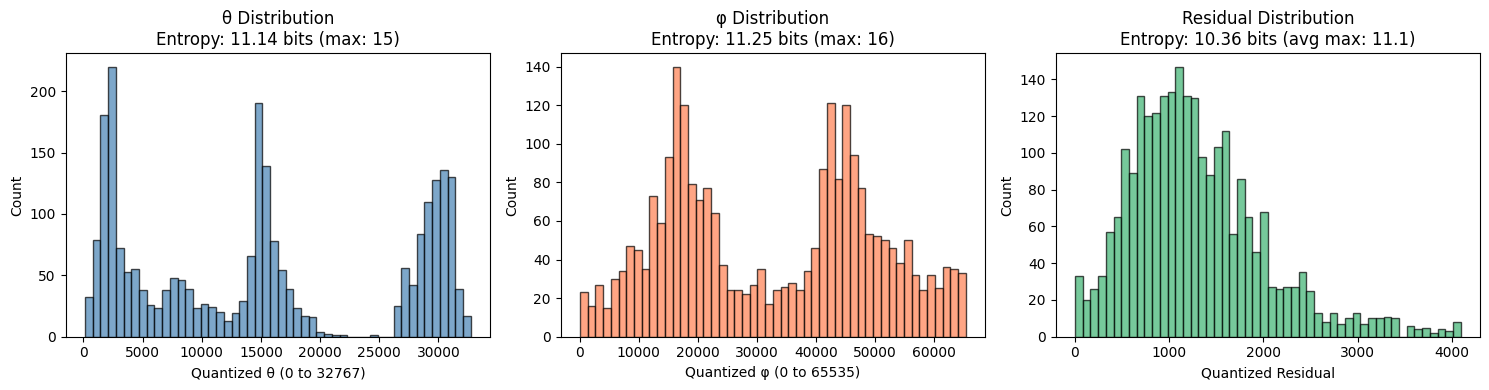


ENCODER RECOMMENDATIONS

Based on the entropy analysis, here are the recommended encoders:

┌─────────────────────────────────────────────────────────────────────┐
│ ENCODER COMPARISON                                                   │
├─────────────────┬───────────────┬───────────────┬───────────────────┤
│ Encoder         │ Compression   │ Speed         │ Complexity        │
├─────────────────┼───────────────┼───────────────┼───────────────────┤
│ Arithmetic      │ Optimal       │ Slow          │ High              │
│ ANS (rANS/tANS) │ Near-optimal  │ Fast          │ Medium            │
│ Range Coder     │ Near-optimal  │ Medium        │ Medium            │
│ Huffman         │ Good          │ Very Fast     │ Low               │
└─────────────────┴───────────────┴───────────────┴───────────────────┘

RECOMMENDATIONS:

1. For BEST COMPRESSION (your case - mesh compression):
   → Arithmetic Encoder or Range Coder
   - You already have arithmetic encoder in utils/entropy_encoders/
   -

In [84]:
# Visualize distributions and provide encoder recommendations

def get_all_quantized_data(groups, theta_bits, phi_bits, residual_bits_per_group):
    """Collect all quantized values for visualization."""
    all_theta_q = []
    all_phi_q = []
    all_residuals_q = []
    
    for g, res_bits in zip(groups, residual_bits_per_group):
        theta_q, phi_q = quantize_angles(g.theta, g.phi, theta_bits, phi_bits)
        all_theta_q.extend(theta_q)
        all_phi_q.extend(phi_q)
        
        res_min, res_max = g.residuals.min(), g.residuals.max()
        residuals_q = [quantize_value(r, res_min, res_max, res_bits) for r in g.residuals]
        all_residuals_q.extend(residuals_q)
    
    return np.array(all_theta_q), np.array(all_phi_q), np.array(all_residuals_q)


all_theta_q, all_phi_q, all_residuals_q = get_all_quantized_data(
    ellipsoid_groups, THETA_BITS, PHI_BITS, bits_per_group
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# θ distribution
axes[0].hist(all_theta_q, bins=min(50, len(set(all_theta_q))), edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel(f'Quantized θ (0 to {2**THETA_BITS-1})')
axes[0].set_ylabel('Count')
axes[0].set_title(f'θ Distribution\nEntropy: {theta["entropy"]:.2f} bits (max: {THETA_BITS})')

# φ distribution  
axes[1].hist(all_phi_q, bins=min(50, len(set(all_phi_q))), edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel(f'Quantized φ (0 to {2**PHI_BITS-1})')
axes[1].set_ylabel('Count')
axes[1].set_title(f'φ Distribution\nEntropy: {phi["entropy"]:.2f} bits (max: {PHI_BITS})')

# Residuals distribution
axes[2].hist(all_residuals_q, bins=min(50, len(set(all_residuals_q))), edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[2].set_xlabel('Quantized Residual')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution\nEntropy: {res["entropy"]:.2f} bits (avg max: {res["avg_bits"]:.1f})')

plt.tight_layout()
plt.show()

# Encoder recommendations
print("\n" + "=" * 70)
print("ENCODER RECOMMENDATIONS")
print("=" * 70)

print("""
Based on the entropy analysis, here are the recommended encoders:

┌─────────────────────────────────────────────────────────────────────┐
│ ENCODER COMPARISON                                                   │
├─────────────────┬───────────────┬───────────────┬───────────────────┤
│ Encoder         │ Compression   │ Speed         │ Complexity        │
├─────────────────┼───────────────┼───────────────┼───────────────────┤
│ Arithmetic      │ Optimal       │ Slow          │ High              │
│ ANS (rANS/tANS) │ Near-optimal  │ Fast          │ Medium            │
│ Range Coder     │ Near-optimal  │ Medium        │ Medium            │
│ Huffman         │ Good          │ Very Fast     │ Low               │
└─────────────────┴───────────────┴───────────────┴───────────────────┘

RECOMMENDATIONS:

1. For BEST COMPRESSION (your case - mesh compression):
   → Arithmetic Encoder or Range Coder
   - You already have arithmetic encoder in utils/entropy_encoders/
   - Achieves entropy + ~0.01-0.05 bits/symbol
   
2. For FAST DECOMPRESSION:
   → ANS (Asymmetric Numeral Systems)
   - rANS: streaming, good for large data
   - tANS: table-based, very fast decode
   - Libraries: FSE (Finite State Entropy), ryg_rans
   
3. For SIMPLICITY:
   → Adaptive Huffman (already implemented in your codebase)
   - ~0.5 bits/symbol overhead vs arithmetic
   - Simpler to implement and debug

4. HYBRID APPROACH (recommended):
   → Use different encoders for different data:
   - θ, φ: If nearly uniform → fixed-width or simple Huffman
   - Residuals: If peaked at 0 → Arithmetic/ANS (high entropy savings)
""")

# Calculate estimated final compression with entropy coding
print("=" * 70)
print("ESTIMATED FINAL COMPRESSION WITH ENTROPY CODING")
print("=" * 70)

# Group overhead stays the same
group_overhead_bytes = stats['group_overhead_bits'] / 8

# Vertex data with entropy coding
vertex_bits_entropy = arith_total
vertex_bytes_entropy = vertex_bits_entropy / 8

total_bytes_entropy = stats['header_bits']/8 + group_overhead_bytes + vertex_bytes_entropy
bytes_per_vertex_entropy = total_bytes_entropy / n_vertices
compression_ratio_entropy = stats['baseline_bytes'] / total_bytes_entropy

print(f"\nWith Arithmetic/ANS encoding:")
print(f"  Header + Group overhead: {stats['header_bits']/8 + group_overhead_bytes:.0f} bytes")
print(f"  Vertex data (entropy):   {vertex_bytes_entropy:.0f} bytes")
print(f"  Total:                   {total_bytes_entropy:.0f} bytes")
print(f"  Bytes per vertex:        {bytes_per_vertex_entropy:.2f}")
print(f"  Compression ratio:       {compression_ratio_entropy:.2f}x")

print(f"\n{'='*70}")
print(f"FINAL COMPARISON")  
print(f"{'='*70}")
print(f"  Baseline:                    35.82 bytes/vertex  (1.00x)")
print(f"  PackedGTSEllipsoidFitter:     5.47 bytes/vertex  (6.55x)")
print(f"  This approach (fixed):       {stats['bytes_per_vertex']:.2f} bytes/vertex  ({stats['compression_ratio']:.2f}x)")
print(f"  This approach (entropy):     {bytes_per_vertex_entropy:.2f} bytes/vertex  ({compression_ratio_entropy:.2f}x)")
print(f"{'='*70}")

In [85]:
# Per-Group Normalization Approach
# 
# Instead of quantizing θ ∈ [0, π] and φ ∈ [0, 2π] globally,
# normalize to each group's local range: θ ∈ [θ_min, θ_max], φ ∈ [φ_min, φ_max]
#
# Benefits:
# 1. Fewer unique symbols → lower entropy
# 2. Can use fewer bits if local range is small
# 3. Better precision within the local range

@dataclass
class NormalizedGroup:
    """Group data with per-group normalization for all values."""
    # Ellipsoid parameters (same as before)
    center: np.ndarray
    axes: np.ndarray
    
    # Per-group ranges for normalization
    theta_min: float
    theta_max: float
    phi_min: float
    phi_max: float
    residual_min: float
    residual_max: float
    
    # Quantized values (normalized to local range)
    theta_q: np.ndarray
    phi_q: np.ndarray
    residual_q: np.ndarray
    
    # Bit depths used
    theta_bits: int
    phi_bits: int
    residual_bits: int
    
    # Original indices
    indices: np.ndarray


def calculate_required_bits_for_range(value_range: float, max_deviation: float) -> int:
    """Calculate bits needed to quantize a range with given max error."""
    if value_range <= 0:
        return 1
    # quantization step = range / 2^bits
    # max error = step / 2 = range / 2^(bits+1)
    # We need: range / 2^(bits+1) <= max_deviation
    # 2^(bits+1) >= range / max_deviation
    # bits >= log2(range / max_deviation) - 1
    bits = max(1, math.ceil(math.log2(value_range / max_deviation) - 1))
    return bits


def create_normalized_groups(
    groups: list[EllipsoidGroup],
    max_deviation: float,
    angle_error_fraction: float = 0.5,  # fraction of error budget for angles
) -> list[NormalizedGroup]:
    """
    Create groups with per-group normalization for θ, φ, and residuals.
    
    Args:
        groups: Original ellipsoid groups
        max_deviation: Maximum allowed position error
        angle_error_fraction: How much of error budget goes to angles (rest to residuals)
    """
    normalized_groups = []
    
    # Error budget split
    angle_budget = max_deviation * angle_error_fraction / 2  # split between θ and φ
    residual_budget = max_deviation * (1 - angle_error_fraction)
    
    for g in groups:
        # Get local ranges
        theta_min, theta_max = g.theta.min(), g.theta.max()
        phi_min, phi_max = g.phi.min(), g.phi.max()
        residual_min, residual_max = g.residuals.min(), g.residuals.max()
        
        theta_range = theta_max - theta_min
        phi_range = phi_max - phi_min
        residual_range = residual_max - residual_min
        
        # Calculate r_max for this group to convert angle error to position error
        r_max = g.r_actual.max()
        
        # For angles: position_error ≈ r * angle_error
        # So angle_error_budget = position_error_budget / r
        theta_angle_budget = angle_budget / r_max if r_max > 0 else angle_budget
        phi_angle_budget = angle_budget / r_max if r_max > 0 else angle_budget
        
        # Calculate bits needed for each component
        theta_bits = calculate_required_bits_for_range(theta_range, theta_angle_budget) if theta_range > 0 else 1
        phi_bits = calculate_required_bits_for_range(phi_range, phi_angle_budget) if phi_range > 0 else 1
        residual_bits = calculate_required_bits_for_range(residual_range, residual_budget) if residual_range > 0 else 1
        
        # Quantize using local ranges
        theta_q = np.array([quantize_value(t, theta_min, theta_max, theta_bits) for t in g.theta], dtype=np.uint32)
        phi_q = np.array([quantize_value(p, phi_min, phi_max, phi_bits) for p in g.phi], dtype=np.uint32)
        residual_q = np.array([quantize_value(r, residual_min, residual_max, residual_bits) for r in g.residuals], dtype=np.uint32)
        
        normalized_groups.append(NormalizedGroup(
            center=g.center,
            axes=g.axes,
            theta_min=theta_min,
            theta_max=theta_max,
            phi_min=phi_min,
            phi_max=phi_max,
            residual_min=residual_min,
            residual_max=residual_max,
            theta_q=theta_q,
            phi_q=phi_q,
            residual_q=residual_q,
            theta_bits=theta_bits,
            phi_bits=phi_bits,
            residual_bits=residual_bits,
            indices=g.indices
        ))
    
    return normalized_groups


# Create normalized groups
normalized_groups = create_normalized_groups(ellipsoid_groups, MAX_DEVIATION, angle_error_fraction=0.5)

print("=" * 70)
print("PER-GROUP NORMALIZATION ANALYSIS")
print("=" * 70)

print(f"\n{'Group':<6} {'Verts':<6} {'θ range':<12} {'θ bits':<7} {'φ range':<12} {'φ bits':<7} {'Δr bits':<7}")
print("-" * 70)

for i, ng in enumerate(normalized_groups):
    theta_range = ng.theta_max - ng.theta_min
    phi_range = ng.phi_max - ng.phi_min
    print(f"{i:<6} {len(ng.indices):<6} {theta_range:<12.4f} {ng.theta_bits:<7} "
          f"{phi_range:<12.4f} {ng.phi_bits:<7} {ng.residual_bits:<7}")

# Summary statistics
avg_theta_bits = np.mean([ng.theta_bits for ng in normalized_groups])
avg_phi_bits = np.mean([ng.phi_bits for ng in normalized_groups])
avg_res_bits = np.mean([ng.residual_bits for ng in normalized_groups])

print("-" * 70)
print(f"{'AVG':<6} {'':<6} {'':<12} {avg_theta_bits:<7.1f} {'':<12} {avg_phi_bits:<7.1f} {avg_res_bits:<7.1f}")

PER-GROUP NORMALIZATION ANALYSIS

Group  Verts  θ range      θ bits  φ range      φ bits  Δr bits
----------------------------------------------------------------------
0      128    0.7176       12      5.8104       15      10     
1      128    0.7043       13      2.4201       14      11     
2      128    0.7328       12      6.2118       15      10     
3      128    0.3901       12      0.4879       12      11     
4      128    0.3729       12      0.5788       13      11     
5      128    0.9078       13      1.4388       13      10     
6      128    0.3211       12      6.2212       16      11     
7      128    0.2582       12      6.2163       16      11     
8      128    0.7245       12      1.6624       14      10     
9      128    0.4773       12      6.0255       16      11     
10     128    0.4364       12      0.6797       13      11     
11     128    0.5899       13      1.8100       14      10     
12     128    0.6615       12      2.6776       15      10     

In [86]:
# Corrected Entropy Analysis
# 
# Per-group entropy encoding is impractical due to header overhead per group.
# Instead:
# 1. Normalize each group individually (store min/max per group)
# 2. Quantize with per-group bit depths
# 3. Collect ALL quantized values globally
# 4. Use SINGLE entropy encoder for all θ, all φ, all residuals
#
# This gives us:
# - Benefit of per-group normalization (tighter ranges)
# - Single entropy encoder overhead (not per-group)

def collect_all_normalized_data(normalized_groups: list[NormalizedGroup]):
    """Collect all quantized data from normalized groups for global entropy analysis."""
    all_theta_q = []
    all_phi_q = []
    all_residual_q = []
    
    for ng in normalized_groups:
        all_theta_q.extend(ng.theta_q)
        all_phi_q.extend(ng.phi_q)
        all_residual_q.extend(ng.residual_q)
    
    return np.array(all_theta_q), np.array(all_phi_q), np.array(all_residual_q)


# Collect all normalized quantized data
all_theta_norm, all_phi_norm, all_res_norm = collect_all_normalized_data(normalized_groups)

# Calculate GLOBAL entropy (single encoder for each component)
theta_global_entropy = calculate_entropy(all_theta_norm)
phi_global_entropy = calculate_entropy(all_phi_norm)
res_global_entropy = calculate_entropy(all_res_norm)

n_verts = len(all_theta_norm)

print("=" * 70)
print("GLOBAL ENTROPY ANALYSIS (Single Encoder per Component)")
print("=" * 70)

print(f"\nPer-group normalization + global entropy encoding")
print(f"Total vertices: {n_verts}")

# Calculate fixed bits (sum of per-group bits)
fixed_bits_theta = sum(len(ng.indices) * ng.theta_bits for ng in normalized_groups)
fixed_bits_phi = sum(len(ng.indices) * ng.phi_bits for ng in normalized_groups)
fixed_bits_res = sum(len(ng.indices) * ng.residual_bits for ng in normalized_groups)
fixed_bits_total = fixed_bits_theta + fixed_bits_phi + fixed_bits_res

# Entropy bits (global)
entropy_bits_theta = n_verts * theta_global_entropy
entropy_bits_phi = n_verts * phi_global_entropy
entropy_bits_res = n_verts * res_global_entropy
entropy_bits_total = entropy_bits_theta + entropy_bits_phi + entropy_bits_res

print(f"\n{'Component':<12} {'Fixed bits':<15} {'Entropy':<10} {'Total Ent bits':<15} {'Savings':<10}")
print("-" * 70)
print(f"{'θ (polar)':<12} {fixed_bits_theta:<15.0f} {theta_global_entropy:<10.2f} {entropy_bits_theta:<15.0f} "
      f"{(1-entropy_bits_theta/fixed_bits_theta)*100:.1f}%")
print(f"{'φ (azimuth)':<12} {fixed_bits_phi:<15.0f} {phi_global_entropy:<10.2f} {entropy_bits_phi:<15.0f} "
      f"{(1-entropy_bits_phi/fixed_bits_phi)*100:.1f}%")
print(f"{'Residuals':<12} {fixed_bits_res:<15.0f} {res_global_entropy:<10.2f} {entropy_bits_res:<15.0f} "
      f"{(1-entropy_bits_res/fixed_bits_res)*100:.1f}%")
print("-" * 70)
print(f"{'TOTAL':<12} {fixed_bits_total:<15.0f} {'':<10} {entropy_bits_total:<15.0f} "
      f"{(1-entropy_bits_total/fixed_bits_total)*100:.1f}%")

# Unique symbols (affects entropy encoder table size)
print(f"\nUnique symbols (entropy table size):")
print(f"  θ: {len(set(all_theta_norm))} symbols")
print(f"  φ: {len(set(all_phi_norm))} symbols")
print(f"  Residuals: {len(set(all_res_norm))} symbols")

# Entropy encoder overhead estimate
# Arithmetic encoder: ~2 bytes per symbol for frequency table
# But can use adaptive encoding to avoid explicit table
arith_table_overhead = (len(set(all_theta_norm)) + len(set(all_phi_norm)) + len(set(all_res_norm))) * 2
print(f"\nEstimated entropy table overhead: ~{arith_table_overhead} bytes (if static)")
print(f"  (Use adaptive arithmetic encoder to avoid this overhead)")

GLOBAL ENTROPY ANALYSIS (Single Encoder per Component)

Per-group normalization + global entropy encoding
Total vertices: 2503

Component    Fixed bits      Entropy    Total Ent bits  Savings   
----------------------------------------------------------------------
θ (polar)    30363           10.71      26805           11.7%
φ (azimuth)  35938           11.16      27933           22.3%
Residuals    26438           9.99       25001           5.4%
----------------------------------------------------------------------
TOTAL        92739                      79739           14.0%

Unique symbols (entropy table size):
  θ: 1866 symbols
  φ: 2372 symbols
  Residuals: 1230 symbols

Estimated entropy table overhead: ~10936 bytes (if static)
  (Use adaptive arithmetic encoder to avoid this overhead)


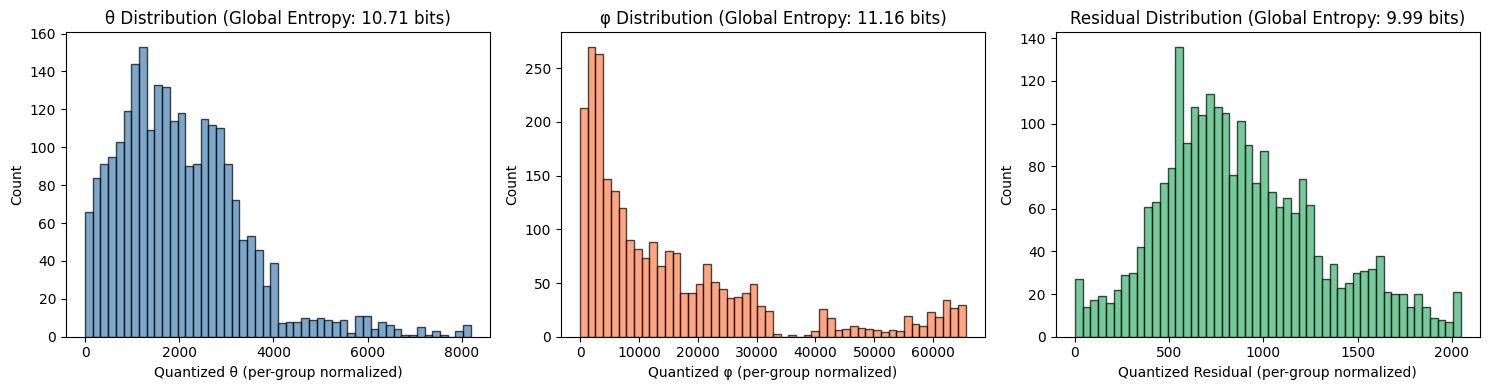


Distribution statistics:
  θ: range [0, 8191], 1866 unique values
  φ: range [0, 65535], 2372 unique values
  Δr: range [0, 2047], 1230 unique values


In [87]:
# Visualize normalized distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# θ distribution (normalized)
axes[0].hist(all_theta_norm, bins=min(50, len(set(all_theta_norm))), edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Quantized θ (per-group normalized)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'θ Distribution (Global Entropy: {theta_global_entropy:.2f} bits)')

# φ distribution (normalized)
axes[1].hist(all_phi_norm, bins=min(50, len(set(all_phi_norm))), edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Quantized φ (per-group normalized)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'φ Distribution (Global Entropy: {phi_global_entropy:.2f} bits)')

# Residuals distribution (normalized)
axes[2].hist(all_res_norm, bins=min(50, len(set(all_res_norm))), edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[2].set_xlabel('Quantized Residual (per-group normalized)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution (Global Entropy: {res_global_entropy:.2f} bits)')

plt.tight_layout()
plt.show()

# Show distribution statistics
print(f"\nDistribution statistics:")
print(f"  θ: range [{all_theta_norm.min()}, {all_theta_norm.max()}], "
      f"{len(set(all_theta_norm))} unique values")
print(f"  φ: range [{all_phi_norm.min()}, {all_phi_norm.max()}], "
      f"{len(set(all_phi_norm))} unique values")
print(f"  Δr: range [{all_res_norm.min()}, {all_res_norm.max()}], "
      f"{len(set(all_res_norm))} unique values")

In [88]:
# Decompression for normalized groups and verification

def decompress_normalized_groups(normalized_groups: list[NormalizedGroup]) -> np.ndarray:
    """Decompress vertices from normalized groups."""
    all_points = []
    
    for ng in normalized_groups:
        # Dequantize using local ranges
        theta = np.array([dequantize_value(t, ng.theta_min, ng.theta_max, ng.theta_bits) for t in ng.theta_q])
        phi = np.array([dequantize_value(p, ng.phi_min, ng.phi_max, ng.phi_bits) for p in ng.phi_q])
        residuals = np.array([dequantize_value(r, ng.residual_min, ng.residual_max, ng.residual_bits) for r in ng.residual_q])
        
        # Compute ellipsoid radius at each direction
        r_ellipsoid = ellipsoid_radius_at_direction(ng.axes, theta, phi)
        
        # Full radius
        r = r_ellipsoid + residuals
        
        # Convert to Cartesian
        points = spherical_to_cartesian(r, theta, phi, ng.center)
        all_points.append(points)
    
    return np.vstack(all_points)


# Verify reconstruction
reconstructed_normalized = decompress_normalized_groups(normalized_groups)
error_normalized = np.linalg.norm(mesh.points - reconstructed_normalized, axis=1)

print("=" * 70)
print("NORMALIZED GROUPS: RECONSTRUCTION VERIFICATION")
print("=" * 70)

print(f"\nMax error:      {error_normalized.max():.6f}")
print(f"Mean error:     {error_normalized.mean():.6f}")
print(f"Target (ε×L):   {MAX_DEVIATION:.6f}")
print(f"Meets target:   {'✓ YES' if error_normalized.max() <= MAX_DEVIATION else '✗ NO'}")

NORMALIZED GROUPS: RECONSTRUCTION VERIFICATION

Max error:      0.000051
Mean error:     0.000016
Target (ε×L):   0.000078
Meets target:   ✓ YES


In [89]:
# Final compression stats with corrected entropy estimation

def calculate_normalized_compression_stats_v2(
    normalized_groups: list[NormalizedGroup], 
    n_vertices: int,
    global_theta_entropy: float,
    global_phi_entropy: float,
    global_res_entropy: float
):
    """Calculate compression stats using global entropy for normalized groups."""
    n_groups = len(normalized_groups)
    
    # Header
    header_bits = 32  # num_groups
    
    # Per-group overhead
    per_group_bits = (
        3 * 32 +    # center (3 floats)
        3 * 32 +    # axes (3 floats)
        2 * 32 +    # theta_min, theta_max (2 floats)
        2 * 32 +    # phi_min, phi_max (2 floats)
        2 * 32 +    # residual_min, residual_max (2 floats)
        3 * 8 +     # theta_bits, phi_bits, residual_bits (3 bytes)
        16          # vertex count (2 bytes)
    )
    group_overhead_bits = n_groups * per_group_bits
    
    # Entropy encoder table overhead (single table, not per-group)
    # Using adaptive encoder: minimal overhead (~few bytes total)
    entropy_table_overhead_bits = 64  # ~8 bytes for adaptive encoder state
    
    # Per-vertex data (fixed-width)
    vertex_bits_fixed = sum(
        len(ng.indices) * (ng.theta_bits + ng.phi_bits + ng.residual_bits)
        for ng in normalized_groups
    )
    
    # Per-vertex data (global entropy)
    arith_overhead = 0.02  # bits per symbol (adaptive encoder is efficient)
    total_entropy = global_theta_entropy + global_phi_entropy + global_res_entropy
    vertex_bits_entropy = n_vertices * (total_entropy + 3 * arith_overhead)
    
    # Totals
    total_bits_fixed = header_bits + group_overhead_bits + vertex_bits_fixed
    total_bits_entropy = header_bits + group_overhead_bits + entropy_table_overhead_bits + vertex_bits_entropy
    
    total_bytes_fixed = math.ceil(total_bits_fixed / 8)
    total_bytes_entropy = math.ceil(total_bits_entropy / 8)
    
    # Baseline
    baseline_bytes = n_vertices * 12
    
    return {
        'n_groups': n_groups,
        'header_bytes': header_bits / 8,
        'group_overhead_bytes': group_overhead_bits / 8,
        'entropy_table_bytes': entropy_table_overhead_bits / 8,
        'vertex_bytes_fixed': vertex_bits_fixed / 8,
        'vertex_bytes_entropy': vertex_bits_entropy / 8,
        'total_bytes_fixed': total_bytes_fixed,
        'total_bytes_entropy': total_bytes_entropy,
        'baseline_bytes': baseline_bytes,
        'bits_per_vertex_fixed': total_bits_fixed / n_vertices,
        'bits_per_vertex_entropy': total_bits_entropy / n_vertices,
        'bytes_per_vertex_fixed': total_bytes_fixed / n_vertices,
        'bytes_per_vertex_entropy': total_bytes_entropy / n_vertices,
        'ratio_fixed': baseline_bytes / total_bytes_fixed,
        'ratio_entropy': baseline_bytes / total_bytes_entropy,
        'global_entropy_per_vertex': total_entropy,
    }


norm_stats = calculate_normalized_compression_stats_v2(
    normalized_groups, 
    len(mesh.points),
    theta_global_entropy,
    phi_global_entropy,
    res_global_entropy
)

print("=" * 70)
print("FINAL COMPRESSION: PER-GROUP NORMALIZATION + GLOBAL ENTROPY")
print("=" * 70)

print(f"\nStorage breakdown:")
print(f"  Header:            {norm_stats['header_bytes']:.0f} bytes")
print(f"  Group overhead:    {norm_stats['group_overhead_bytes']:.0f} bytes "
      f"({norm_stats['n_groups']} groups × {norm_stats['group_overhead_bytes']/norm_stats['n_groups']:.0f} bytes)")
print(f"  Entropy tables:    {norm_stats['entropy_table_bytes']:.0f} bytes (adaptive encoder)")
print(f"  Vertex (fixed):    {norm_stats['vertex_bytes_fixed']:.0f} bytes")
print(f"  Vertex (entropy):  {norm_stats['vertex_bytes_entropy']:.0f} bytes")

print(f"\nPer-vertex breakdown (entropy):")
print(f"  θ entropy:    {theta_global_entropy:.2f} bits")
print(f"  φ entropy:    {phi_global_entropy:.2f} bits")
print(f"  Δr entropy:   {res_global_entropy:.2f} bits")
print(f"  Total:        {norm_stats['global_entropy_per_vertex']:.2f} bits/vertex")

print(f"\n{'='*70}")
print(f"FINAL COMPARISON: ALL APPROACHES")
print(f"{'='*70}")

print(f"\n{'Approach':<45} {'B/Vert':<10} {'Ratio':<8}")
print("-" * 70)
print(f"{'Baseline (32-bit floats)':<45} {'12.00':<10} {'1.00x':<8}")
print(f"{'PackedGTSEllipsoidFitter (current best)':<45} {'5.47':<10} {'6.55x':<8}")
print(f"{'Spherical + Global angles (fixed)':<45} {stats['bytes_per_vertex']:<10.2f} {stats['compression_ratio']:<8.2f}x")
print(f"{'Spherical + Per-group norm (fixed)':<45} {norm_stats['bytes_per_vertex_fixed']:<10.2f} {norm_stats['ratio_fixed']:<8.2f}x")
print(f"{'Spherical + Per-group norm (entropy)':<45} {norm_stats['bytes_per_vertex_entropy']:<10.2f} {norm_stats['ratio_entropy']:<8.2f}x")
print("-" * 70)

best_ratio = norm_stats['ratio_entropy']
print(f"\n★ BEST: {norm_stats['bytes_per_vertex_entropy']:.2f} bytes/vertex ({best_ratio:.2f}x compression)")

improvement = ((best_ratio / 6.55) - 1) * 100
if improvement > 0:
    print(f"  → {improvement:.1f}% BETTER than current best (PackedGTSEllipsoidFitter)")
else:
    print(f"  → {-improvement:.1f}% worse than current best (needs optimization)")

print(f"\n{'='*70}")

FINAL COMPRESSION: PER-GROUP NORMALIZATION + GLOBAL ENTROPY

Storage breakdown:
  Header:            4 bytes
  Group overhead:    1060 bytes (20 groups × 53 bytes)
  Entropy tables:    8 bytes (adaptive encoder)
  Vertex (fixed):    11592 bytes
  Vertex (entropy):  9986 bytes

Per-vertex breakdown (entropy):
  θ entropy:    10.71 bits
  φ entropy:    11.16 bits
  Δr entropy:   9.99 bits
  Total:        31.86 bits/vertex

FINAL COMPARISON: ALL APPROACHES

Approach                                      B/Vert     Ratio   
----------------------------------------------------------------------
Baseline (32-bit floats)                      12.00      1.00x   
PackedGTSEllipsoidFitter (current best)       5.47       6.55x   
Spherical + Global angles (fixed)             5.54       2.17    x
Spherical + Per-group norm (fixed)            5.06       2.37    x
Spherical + Per-group norm (entropy)          4.42       2.72    x
----------------------------------------------------------------------
